Upload your image file:


Saving images.jpg to images.jpg
Loaded: images.jpg

 Original Image:


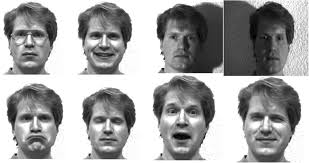


 Grayscale (intensity only):


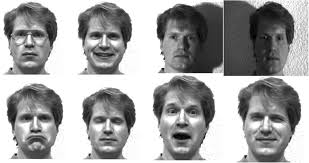


 Edge Map (Canny):


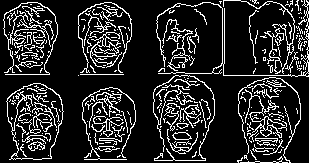


 Integral Image (cumulative sums):


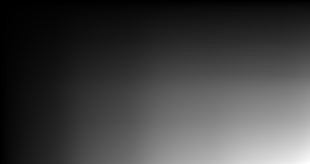


 Faces found: 8

 Final Detection Result:


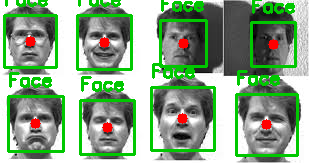

In [3]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
from google.colab import files
from IPython.display import display
import ipywidgets as widgets

# --- Step 1: Upload your image ---
print("Upload your image file:")
uploaded = files.upload()
filename = list(uploaded.keys())[0]
print(f"Loaded: {filename}")

# --- Step 2: Read and show original ---
image = cv2.imread(filename)
print("\n Original Image:")
cv2_imshow(image)

# --- Step 3: Convert to grayscale (strip color, keep structure) ---
intensity_map = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
print("\n Grayscale (intensity only):")
cv2_imshow(intensity_map)

# --- Step 4: Edge detection (find sharp intensity gradients) ---
edge_map = cv2.Canny(intensity_map, threshold1=80, threshold2=160)
print("\n Edge Map (Canny):")
cv2_imshow(edge_map)

# --- Step 5: Integral image (2D prefix sums for fast rect queries) ---
prefix_sums = cv2.integral(intensity_map)
prefix_display = cv2.normalize(prefix_sums, None, 0, 255, cv2.NORM_MINMAX)
prefix_display = np.uint8(prefix_display)
print("\n Integral Image (cumulative sums):")
cv2_imshow(prefix_display)

# --- Step 6: Face detection ---
detector = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

detections = detector.detectMultiScale(
    intensity_map, scaleFactor=1.05, minNeighbors=6
)

result = image.copy()
print(f"\n Faces found: {len(detections)}")

for (x, y, w, h) in detections:
    # Bounding box
    cv2.rectangle(result, (x, y), (x + w, y + h), (0, 200, 0), 2)
    # Center point
    cx, cy = x + w // 2, y + h // 2
    cv2.circle(result, (cx, cy), 5, (0, 0, 255), -1)
    # Label
    cv2.putText(result, "Face", (x, y - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 200, 0), 2)

print("\n Final Detection Result:")
cv2_imshow(result)